# BD PowerCast — Final Evaluation

## Best Model: Adaptive Gated Ramp-Aware Temporal Network

Model selection was completed using the validation set.

- Best traditional model: LightGBM — Validation MAPE: 1.9309%
- Custom Model A — Validation MAPE: 1.7805%
- Custom Model B — Validation MAPE: 1.6638%

Custom Model B was selected as the final architecture.

This notebook evaluates the selected model on the held-out test period
(2024-01-01 onward).

The test set is used only for final evaluation.

import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5050


In [2]:
df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["datetime"].min(),
    "→",
    df["datetime"].max()
)

Dataset shape: (89101, 61)
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00


recreate the exact Model B lag features

In [3]:
# Recent lags
df["lag_1"] = df["demand_mw_clean"].shift(1)
df["lag_2"] = df["demand_mw_clean"].shift(2)
df["lag_3"] = df["demand_mw_clean"].shift(3)

# Daily lags
df["lag_24"] = df["demand_mw_clean"].shift(24)
df["lag_48"] = df["demand_mw_clean"].shift(48)
df["lag_72"] = df["demand_mw_clean"].shift(72)

# Weekly lags
df["lag_168"] = df["demand_mw_clean"].shift(168)
df["lag_336"] = df["demand_mw_clean"].shift(336)
df["lag_504"] = df["demand_mw_clean"].shift(504)
df["lag_672"] = df["demand_mw_clean"].shift(672)

print("Lag features created.")

Lag features created.


rolling features

In [4]:
past_demand = df["demand_mw_clean"].shift(1)

df["rolling_mean_3"] = (
    past_demand.rolling(3).mean()
)

df["rolling_mean_6"] = (
    past_demand.rolling(6).mean()
)

df["rolling_mean_24"] = (
    past_demand.rolling(24).mean()
)

df["rolling_std_24"] = (
    past_demand.rolling(24).std()
)

df["rolling_max_24"] = (
    past_demand.rolling(24).max()
)

df["rolling_min_24"] = (
    past_demand.rolling(24).min()
)

df["rolling_mean_168"] = (
    past_demand.rolling(168).mean()
)

print("Rolling features created.")

Rolling features created.


calendar features

In [5]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

df["month_sin"] = np.sin(
    2 * np.pi * (df["month"] - 1) / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * (df["month"] - 1) / 12
)

df["is_friday"] = (
    df["day_of_week"] == 4
).astype(int)

print("Calendar features created.")

Calendar features created.


Model B ramp features

In [6]:
df["change_1"] = (
    df["demand_mw_clean"].shift(1)
    - df["demand_mw_clean"].shift(2)
)

df["change_2"] = (
    df["demand_mw_clean"].shift(2)
    - df["demand_mw_clean"].shift(3)
)

df["change_3"] = (
    df["demand_mw_clean"].shift(3)
    - df["demand_mw_clean"].shift(4)
)

df["recent_vs_daily"] = (
    df["lag_1"] - df["lag_24"]
)

df["recent_vs_weekly"] = (
    df["lag_1"] - df["lag_168"]
)

df["rolling_max_6"] = (
    past_demand.rolling(6).max()
)

df["rolling_min_6"] = (
    past_demand.rolling(6).min()
)

df["range_6"] = (
    df["rolling_max_6"]
    - df["rolling_min_6"]
)

df["rolling_std_6"] = (
    past_demand.rolling(6).std()
)

print("Ramp features created.")

Ramp features created.


define the exact feature groups

In [7]:
recent_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_24"
]

daily_features = [
    "lag_24",
    "lag_48",
    "lag_72",
    "rolling_mean_24",
    "rolling_max_24",
    "rolling_min_24"
]

weekly_features = [
    "lag_168",
    "lag_336",
    "lag_504",
    "lag_672",
    "rolling_mean_168"
]

calendar_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_friday"
]

ramp_features = [
    "change_1",
    "change_2",
    "change_3",
    "recent_vs_daily",
    "recent_vs_weekly",
    "range_6",
    "rolling_std_6"
]

target = "demand_mw_clean"

rebuild the final modeling dataset

In [8]:
all_features = (
    recent_features
    + daily_features
    + weekly_features
    + calendar_features
    + ramp_features
)

final_df = df[
    ["datetime", "row_observed", target]
    + all_features
].copy()

final_df = final_df[
    final_df["row_observed"] == 1
]

final_df = final_df.dropna(
    subset=[target] + all_features
).reset_index(drop=True)

print("Final dataset shape:", final_df.shape)

print(
    "Missing values:",
    final_df[
        all_features + [target]
    ].isnull().sum().sum()
)

Final dataset shape: (58429, 34)
Missing values: 0


recreate the locked split

In [9]:
train_final = final_df[
    final_df["datetime"] < "2023-01-01"
].copy()

val_final = final_df[
    (final_df["datetime"] >= "2023-01-01") &
    (final_df["datetime"] < "2024-01-01")
].copy()

test_final = final_df[
    final_df["datetime"] >= "2024-01-01"
].copy()

print("Train:", len(train_final))
print("Validation:", len(val_final))
print("Test:", len(test_final))

print("\nTest period:")
print(
    test_final["datetime"].min(),
    "→",
    test_final["datetime"].max()
)

Train: 42521
Validation: 5662
Test: 10246

Test period:
2024-01-06 22:00:00 → 2025-06-17 12:00:00


fit scalers on training data only

In [10]:
recent_scaler = StandardScaler()
daily_scaler = StandardScaler()
weekly_scaler = StandardScaler()
calendar_scaler = StandardScaler()
ramp_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit ONLY on the original training period
X_recent_train = recent_scaler.fit_transform(
    train_final[recent_features]
)

X_daily_train = daily_scaler.fit_transform(
    train_final[daily_features]
)

X_weekly_train = weekly_scaler.fit_transform(
    train_final[weekly_features]
)

X_calendar_train = calendar_scaler.fit_transform(
    train_final[calendar_features]
)

X_ramp_train = ramp_scaler.fit_transform(
    train_final[ramp_features]
)

y_train_scaled = target_scaler.fit_transform(
    train_final[[target]]
).flatten()

print("Training scalers fitted.")

Training scalers fitted.


transform the untouched test set

In [11]:
X_recent_test = recent_scaler.transform(
    test_final[recent_features]
)

X_daily_test = daily_scaler.transform(
    test_final[daily_features]
)

X_weekly_test = weekly_scaler.transform(
    test_final[weekly_features]
)

X_calendar_test = calendar_scaler.transform(
    test_final[calendar_features]
)

X_ramp_test = ramp_scaler.transform(
    test_final[ramp_features]
)

y_test_scaled = target_scaler.transform(
    test_final[[target]]
).flatten()

print("Test data transformed.")

Test data transformed.


build the test DataLoader

In [12]:
def to_tensor(data):
    return torch.tensor(
        data,
        dtype=torch.float32
    )

test_dataset = TensorDataset(
    to_tensor(X_recent_test),
    to_tensor(X_daily_test),
    to_tensor(X_weekly_test),
    to_tensor(X_calendar_test),
    to_tensor(X_ramp_test),
    to_tensor(y_test_scaled)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    pin_memory=True
)

print("Test samples:", len(test_dataset))

Test samples: 10246


redefine Custom Model B exactly

In [13]:
class AdaptiveGatedDemandNet(nn.Module):

    def __init__(
        self,
        recent_dim,
        daily_dim,
        weekly_dim,
        calendar_dim,
        ramp_dim
    ):
        super().__init__()

        self.recent_branch = nn.Sequential(
            nn.Linear(recent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.daily_branch = nn.Sequential(
            nn.Linear(daily_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.weekly_branch = nn.Sequential(
            nn.Linear(weekly_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.ramp_branch = nn.Sequential(
            nn.Linear(ramp_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.calendar_branch = nn.Sequential(
            nn.Linear(calendar_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.gate = nn.Sequential(
            nn.Linear(24, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

        self.fusion = nn.Sequential(
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(48, 24),
            nn.ReLU(),

            nn.Linear(24, 1)
        )

    def forward(
        self,
        recent,
        daily,
        weekly,
        calendar,
        ramp
    ):

        recent_out = self.recent_branch(recent)
        daily_out = self.daily_branch(daily)
        weekly_out = self.weekly_branch(weekly)
        ramp_out = self.ramp_branch(ramp)

        calendar_out = self.calendar_branch(
            calendar
        )

        gate_context = torch.cat(
            [calendar_out, ramp_out],
            dim=1
        )

        gate_weights = torch.softmax(
            self.gate(gate_context),
            dim=1
        )

        branch_outputs = torch.stack(
            [
                recent_out,
                daily_out,
                weekly_out,
                ramp_out
            ],
            dim=1
        )

        weighted_temporal = (
            branch_outputs
            * gate_weights.unsqueeze(-1)
        ).sum(dim=1)

        combined = torch.cat(
            [
                weighted_temporal,
                calendar_out
            ],
            dim=1
        )

        prediction = self.fusion(
            combined
        )

        return (
            prediction.squeeze(1),
            gate_weights
        )

initialize and load the saved model

In [14]:
model_b_final = AdaptiveGatedDemandNet(
    recent_dim=len(recent_features),
    daily_dim=len(daily_features),
    weekly_dim=len(weekly_features),
    calendar_dim=len(calendar_features),
    ramp_dim=len(ramp_features)
).to(device)

model_b_final.load_state_dict(
    torch.load(
        "../models/custom_model_b.pth",
        map_location=device
    )
)

model_b_final.eval()

print("Custom Model B loaded successfully.")
print("Device:", device)

Custom Model B loaded successfully.
Device: cuda


confirm parameter count

In [15]:
total_params = sum(
    p.numel()
    for p in model_b_final.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    f"{total_params:,}"
)

Trainable parameters: 6,605


run the one-time test prediction

In [16]:
test_predictions_scaled = []
test_gate_weights = []

model_b_final.eval()

with torch.no_grad():

    for batch in test_loader:

        recent, daily, weekly, calendar, ramp, _ = batch

        recent = recent.to(device)
        daily = daily.to(device)
        weekly = weekly.to(device)
        calendar = calendar.to(device)
        ramp = ramp.to(device)

        predictions, gate_weights = model_b_final(
            recent,
            daily,
            weekly,
            calendar,
            ramp
        )

        test_predictions_scaled.extend(
            predictions.cpu().numpy()
        )

        test_gate_weights.append(
            gate_weights.cpu().numpy()
        )

In [17]:
model_b_test_pred = (
    target_scaler
    .inverse_transform(
        np.array(
            test_predictions_scaled
        ).reshape(-1, 1)
    )
    .flatten()
)

test_gate_weights = np.vstack(
    test_gate_weights
)

print(
    "Predictions:",
    len(model_b_test_pred)
)

print(
    "Gate matrix:",
    test_gate_weights.shape
)

Predictions: 10246
Gate matrix: (10246, 4)


final test metrics

In [19]:
y_test_actual = (
    test_final[target]
    .to_numpy()
)

test_mae = mean_absolute_error(
    y_test_actual,
    model_b_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        model_b_test_pred
    )
)

test_mape = (
    np.mean(
        np.abs(
            (
                y_test_actual
                - model_b_test_pred
            )
            / y_test_actual
        )
    )
    * 100
)

test_r2 = r2_score(
    y_test_actual,
    model_b_test_pred
)

print("FINAL TEST RESULTS")
print("=" * 35)

print(f"MAE  : {test_mae:.2f} MW")
print(f"RMSE : {test_rmse:.2f} MW")
print(f"MAPE : {test_mape:.4f}%")
print(f"R²   : {test_r2:.4f}")

FINAL TEST RESULTS
MAE  : 206.39 MW
RMSE : 287.70 MW
MAPE : 1.8297%
R²   : 0.9845


final comparison table

In [20]:
final_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Custom Model B"
    ],

    "Test_MAPE": [
        10.76,
        2.51,
        2.72,
        2.92,
        2.74,
        test_mape
    ]
})

final_comparison = final_comparison.sort_values(
    "Test_MAPE"
).reset_index(drop=True)

final_comparison

,Model,Test_MAPE
0,Custom Model B,1.829697
1,Linear Regression,2.510000
2,Random Forest,2.720000
3,LightGBM,2.740000
4,XGBoost,2.920000
5,Seasonal Naive,10.760000


In [21]:
import os

os.makedirs("../results", exist_ok=True)

final_metrics = pd.DataFrame([
    {
        "Model": "Custom Model B - Adaptive Gated Ramp",
        "Test_MAE_MW": test_mae,
        "Test_RMSE_MW": test_rmse,
        "Test_MAPE": test_mape,
        "Test_R2": test_r2,
        "Parameters": total_params
    }
])

final_metrics.to_csv(
    "../results/final_model_b_test_metrics.csv",
    index=False
)

final_comparison.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Final results saved.")

Final results saved.


In [22]:
prediction_df = test_final[
    ["datetime", target]
].reset_index(drop=True).copy()

prediction_df.rename(
    columns={
        target: "actual_demand_mw"
    },
    inplace=True
)

prediction_df["predicted_demand_mw"] = (
    model_b_test_pred
)

prediction_df["error_mw"] = (
    prediction_df["actual_demand_mw"]
    - prediction_df["predicted_demand_mw"]
)

prediction_df["absolute_error_mw"] = (
    np.abs(prediction_df["error_mw"])
)

prediction_df["percentage_error"] = (
    prediction_df["absolute_error_mw"]
    / prediction_df["actual_demand_mw"]
) * 100

prediction_df.to_csv(
    "../results/final_test_predictions.csv",
    index=False
)

prediction_df.head()

,datetime,actual_demand_mw,predicted_demand_mw,error_mw,absolute_error_mw,percentage_error
0,2024-01-06 22:00:00,7702.0,7871.482422,-169.482422,169.482422,2.200499
1,2024-01-06 23:00:00,7195.0,7289.341797,-94.341797,94.341797,1.311213
2,2024-01-07 00:00:00,6578.0,6840.178223,-262.178223,262.178223,3.985683
3,2024-01-07 01:00:00,6284.0,6376.849121,-92.849121,92.849121,1.477548
4,2024-01-07 02:00:00,6000.0,6175.010254,-175.010254,175.010254,2.916838


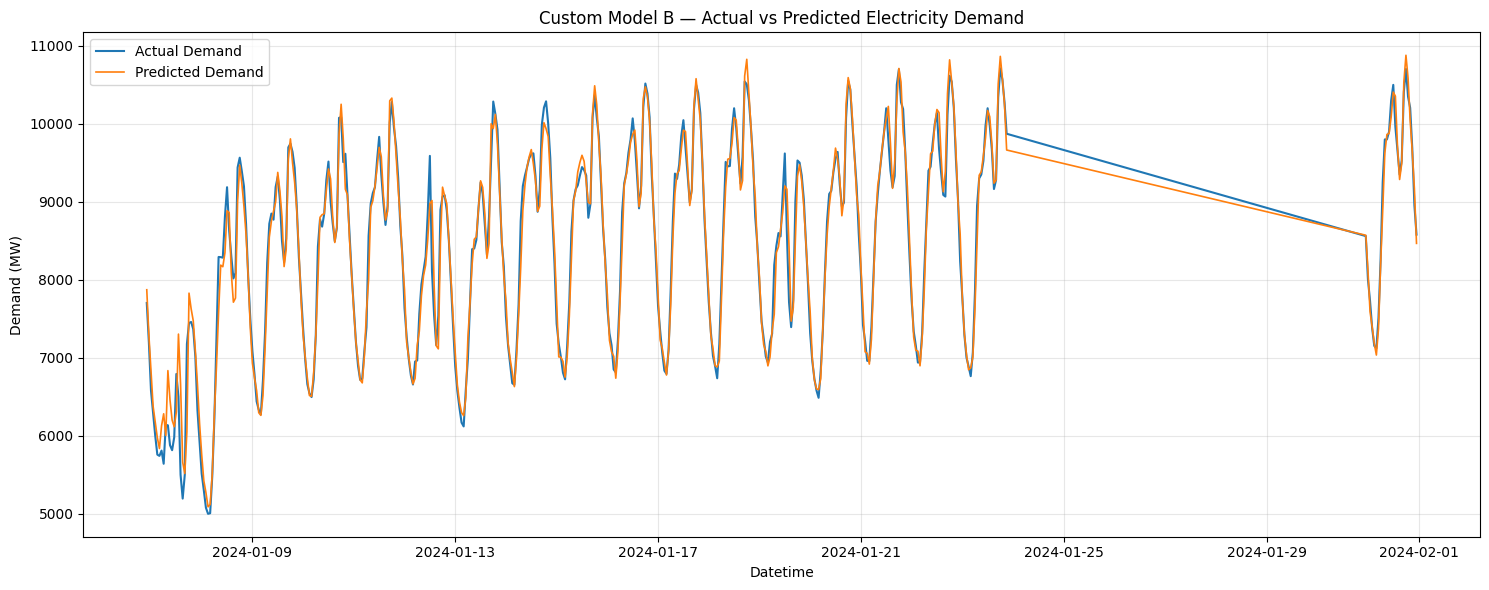

In [23]:
plot_df = prediction_df[
    (prediction_df["datetime"] >= "2024-01-01") &
    (prediction_df["datetime"] < "2024-02-01")
]

plt.figure(figsize=(15, 6))

plt.plot(
    plot_df["datetime"],
    plot_df["actual_demand_mw"],
    label="Actual Demand",
    linewidth=1.5
)

plt.plot(
    plot_df["datetime"],
    plot_df["predicted_demand_mw"],
    label="Predicted Demand",
    linewidth=1.2
)

plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.title(
    "Custom Model B — Actual vs Predicted Electricity Demand"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

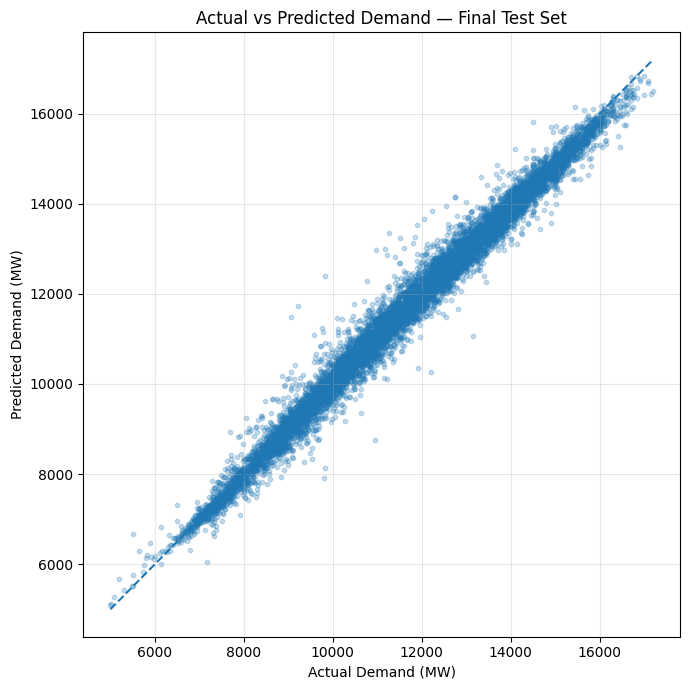

In [24]:
plt.figure(figsize=(7, 7))

plt.scatter(
    prediction_df["actual_demand_mw"],
    prediction_df["predicted_demand_mw"],
    alpha=0.25,
    s=10
)

minimum = min(
    prediction_df["actual_demand_mw"].min(),
    prediction_df["predicted_demand_mw"].min()
)

maximum = max(
    prediction_df["actual_demand_mw"].max(),
    prediction_df["predicted_demand_mw"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Demand (MW)")
plt.ylabel("Predicted Demand (MW)")
plt.title(
    "Actual vs Predicted Demand — Final Test Set"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()